In [12]:
# Cell 1: Cấu hình mô phỏng ⚙️
import torch

class SimulationConfig:
    # === 1. Cấu hình kiến trúc HSFL ===
    ALGORITHM = 'hsfl'
    NUM_TIERS = 3              # Tổng số tầng (M). Ví dụ: 3 = Client(1) + Edge(2) + Cloud(3)
    
    # Chỉ số lớp cắt (Split Layers). Length = NUM_TIERS - 1
    # Ví dụ cho VGG16 (16 lớp CNN/FC): [5, 12] -> Tier 1: 0-4, Tier 2: 5-11, Tier 3: 12-15
    # Cần điều chỉnh dựa trên mô hình thực tế.
    SPLIT_LAYERS = [5, 12] 
    
    # Khoảng thời gian tổng hợp (Aggregation Intervals). Length = NUM_TIERS - 1
    # I = [I_1, I_2, ..., I_(M-1)]. I_m: Tầng m tổng hợp mỗi I_m vòng.
    # [cite_start]Tầng cao nhất (M) luôn tổng hợp (I_M = 1 implicitly) [cite: 103]
    AGGREGATION_INTERVALS = [20, 5] # Ví dụ: Client models agg every 20 rounds, Edge models every 5 rounds

    GLOBAL_ROUNDS = 50          # Tổng số vòng huấn luyện (R)
    
    # === 2. Cấu hình huấn luyện ===
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001       # SFL thường cần LR nhỏ hơn

    # === 3. Cấu hình hệ thống và đường dẫn ===
    CONFIG_PATH = '../configs/config.yaml'
    DATA_PATH = '../data'
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 42

config = SimulationConfig()

# --- Kiểm tra cấu hình HSFL ---
assert len(config.SPLIT_LAYERS) == config.NUM_TIERS - 1, "Số lớp cắt phải là NUM_TIERS - 1"
assert len(config.AGGREGATION_INTERVALS) == config.NUM_TIERS - 1, "Số khoảng tổng hợp phải là NUM_TIERS - 1"
print(f"Cấu hình HSFL: {config.NUM_TIERS} tầng.")
print(f"  - Lớp cắt: {config.SPLIT_LAYERS}")
print(f"  - Khoảng tổng hợp: {config.AGGREGATION_INTERVALS}")

Cấu hình HSFL: 3 tầng.
  - Lớp cắt: [5, 12]
  - Khoảng tổng hợp: [20, 5]


In [13]:
# Cell 2: Tải cấu hình, dữ liệu và thiết lập cấu trúc phân cấp 📦
import yaml, torch, numpy as np, time, copy, os
import matplotlib.pyplot as plt
from torch import nn
from torch.optim import SGD # SFL often uses SGD
import sys
sys.path.append(os.path.abspath(os.path.join('..')))
from src.dataset_preparation import prepare_data 
from src.monitoring_utils import ResourceMonitor, shutdown_pynvml


# --- Setup & Load Config ---
torch.manual_seed(config.SEED); np.random.seed(config.SEED)
print(f"Đang đọc file cấu hình từ: {config.CONFIG_PATH}")
with open(config.CONFIG_PATH, 'r') as f: loaded_config = yaml.safe_load(f)
data_params = loaded_config['data_config']
print(f"Đã tải cấu hình dữ liệu: {data_params}")

# --- Prepare Data ---
client_loaders, test_loader, class_names = prepare_data(
    data_path=config.DATA_PATH, batch_size=config.BATCH_SIZE, seed=config.SEED, **data_params
)
total_num_clients = len(client_loaders)
print(f"\nĐã khởi tạo dữ liệu cho tổng số {total_num_clients} client.")
print(f"Sử dụng thiết bị: {config.DEVICE}")

# --- Thiết lập cấu trúc phân cấp (Ví dụ: Balanced Tree cho 3 Tầng) ---
# Giả định Tầng 2 là Edge Servers. Cần biết có bao nhiêu Edge Server.
# Lấy số lượng thực thể ở Tầng 2 từ số client và cách chia (ví dụ: 4 client/edge)
clients_per_edge = 4 # Tham số ví dụ, bạn có thể đặt nó vào config
num_edges = (total_num_clients + clients_per_edge - 1) // clients_per_edge # Tính số edge cần thiết

# Chia client_loaders cho các edge server
client_groups_for_edges = np.array_split(client_loaders, num_edges)
# Lưu lại ID client thuộc về edge nào
client_to_edge_map = {}
edge_client_indices = [] # List of lists: [[client_ids_edge0], [client_ids_edge1], ...]
current_client_idx = 0
for edge_id, group in enumerate(client_groups_for_edges):
    ids_for_this_edge = []
    for _ in group:
        client_to_edge_map[current_client_idx] = edge_id
        ids_for_this_edge.append(current_client_idx)
        current_client_idx += 1
    edge_client_indices.append(ids_for_this_edge)
    
print(f"\nĐã thiết lập cấu trúc phân cấp:")
print(f"  - Tầng 1 (Clients): {total_num_clients}")
print(f"  - Tầng 2 (Edges): {num_edges}")
for i, group in enumerate(client_groups_for_edges):
    print(f"    - Edge {i}: Phục vụ {len(group)} client (IDs: {edge_client_indices[i]})")
print(f"  - Tầng 3 (Cloud): 1")

Đang đọc file cấu hình từ: ../configs/config.yaml
Đã tải cấu hình dữ liệu: {'dataset_name': 'cifar10', 'distribution_mode': 'non_iid_shards', 'num_clients': 10, 'shards_per_client': 2, 'dirichlet_alpha': 0.5}

Đã khởi tạo dữ liệu cho tổng số 10 client.
Sử dụng thiết bị: cuda

Đã thiết lập cấu trúc phân cấp:
  - Tầng 1 (Clients): 10
  - Tầng 2 (Edges): 3
    - Edge 0: Phục vụ 4 client (IDs: [0, 1, 2, 3])
    - Edge 1: Phục vụ 3 client (IDs: [4, 5, 6])
    - Edge 2: Phục vụ 3 client (IDs: [7, 8, 9])
  - Tầng 3 (Cloud): 1


In [14]:
# Cell 3: Định nghĩa mô hình (Chia thành nhiều phần) 🧠
from torchvision import models
import collections

def create_hsfl_models(base_model_name='vgg16', num_classes=10, split_layers=[], num_tiers=3, pretrained=False):
    """Chia một mô hình base thành M phần cho HSFL."""
    
    # Tải mô hình gốc (ví dụ: VGG16)
    if base_model_name == 'vgg16':
        base_model = models.vgg16(pretrained=pretrained)
        # Tách features và classifier
        features = list(base_model.features.children())
        avgpool = [base_model.avgpool]
        classifier = list(base_model.classifier.children())
        # Thay đổi lớp cuối cùng của classifier cho phù hợp num_classes
        num_ftrs = base_model.classifier[-1].in_features
        classifier[-1] = nn.Linear(num_ftrs, num_classes)
        all_layers = features + avgpool + [nn.Flatten(1)] + classifier
        
    # Thêm các mô hình khác nếu cần
    # elif base_model_name == 'resnet18':
    #    ... 
    else:
        raise ValueError(f"Mô hình gốc '{base_model_name}' chưa được hỗ trợ.")

    total_layers = len(all_layers)
    print(f"Mô hình gốc '{base_model_name}' có tổng cộng {total_layers} khối/lớp chính.")

    # Tạo danh sách các điểm cắt bao gồm đầu và cuối
    cuts = [0] + split_layers + [total_layers]
    
    # Tạo M mô hình con
    model_parts = []
    for i in range(num_tiers):
        start_layer = cuts[i]
        end_layer = cuts[i+1]
        sub_model_layers = all_layers[start_layer:end_layer]
        model_parts.append(nn.Sequential(*sub_model_layers))
        print(f"  - Model Tầng {i+1}: Lớp {start_layer} đến {end_layer-1}")
        
    return model_parts

# --- Tạo các mô hình HSFL ---
input_size = 64 if data_params['dataset_name'] == 'tiny_imagenet' else 32 # VGG cần input cố định? Không hẳn.
hsfl_models_defs = create_hsfl_models(
    num_classes=len(class_names), 
    split_layers=config.SPLIT_LAYERS, 
    num_tiers=config.NUM_TIERS
)

# --- Khởi tạo các instance mô hình ---
# Tầng 1: Mỗi client có model riêng
client_models = [copy.deepcopy(hsfl_models_defs[0]).to(config.DEVICE) for _ in range(total_num_clients)]

# Tầng > 1: Mỗi thực thể (edge/cloud) có 1 model chia sẻ
# Lưu theo dạng: {tier_index: [model_entity_0, model_entity_1, ...]}
shared_models = collections.defaultdict(list)
num_entities_per_tier = [total_num_clients] + [num_edges] * (config.NUM_TIERS - 2) + [1] # [N, num_edges, ..., 1]

for tier_idx in range(1, config.NUM_TIERS): # Bắt đầu từ Tầng 2
    num_entities = num_entities_per_tier[tier_idx]
    print(f"Khởi tạo {num_entities} model(s) cho Tầng {tier_idx+1}")
    for _ in range(num_entities):
        shared_models[tier_idx].append(copy.deepcopy(hsfl_models_defs[tier_idx]).to(config.DEVICE))

# Khởi tạo optimizers
client_optimizers = [SGD(model.parameters(), lr=config.LEARNING_RATE, momentum=0.9) for model in client_models]
shared_optimizers = collections.defaultdict(list)
for tier_idx in range(1, config.NUM_TIERS):
    for model in shared_models[tier_idx]:
        shared_optimizers[tier_idx].append(SGD(model.parameters(), lr=config.LEARNING_RATE, momentum=0.9))

criterion = nn.CrossEntropyLoss()
monitor = ResourceMonitor()

Mô hình gốc 'vgg16' có tổng cộng 40 khối/lớp chính.
  - Model Tầng 1: Lớp 0 đến 4
  - Model Tầng 2: Lớp 5 đến 11
  - Model Tầng 3: Lớp 12 đến 39
Khởi tạo 3 model(s) cho Tầng 2
Khởi tạo 1 model(s) cho Tầng 3


In [15]:
# Cell 4: Logic cốt lõi của Hierarchical Split Learning 🤖
import torch.nn.functional as F

def calculate_tensor_size_mb(tensor):
    """Tính kích thước của một tensor (tính bằng Megabytes)."""
    if tensor is None: return 0
    return tensor.element_size() * tensor.nelement() / (1024**2)

def hsfl_evaluate(tier_models, test_loader):
    """Đánh giá hiệu suất của chuỗi mô hình HSFL."""
    # tier_models is a list: [client_model_0, edge_model_for_client_0, cloud_model]
    for model in tier_models: model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(config.DEVICE), target.to(config.DEVICE)
            
            # Forward pass qua các tầng
            activations = data
            for model in tier_models:
                activations = model(activations)
            logits = activations # Output của tầng cuối cùng
            
            test_loss += F.cross_entropy(logits, target, reduction='sum').item()
            pred = logits.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            
    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)
    return test_loss, accuracy

def get_entity_id(tier_idx, client_id):
    """Xác định ID của thực thể chứa mô hình tầng tier_idx cho client_id."""
    if tier_idx == 0: return client_id # Tầng 1, mỗi client là 1 thực thể
    if tier_idx == 1: return client_to_edge_map[client_id] # Tầng 2, map client -> edge
    # Các tầng cao hơn (nếu có) thường chỉ có 1 thực thể (cloud)
    return 0

def aggregate_models(weights_list):
    """Averages a list of model state dictionaries (weights)."""
    start_time = time.time()
    if not weights_list:
        return None, 0 # Handle empty list case

    # Deep copy the first state dict to use as the base for aggregation
    aggregated_weights = copy.deepcopy(weights_list[0])

    # Zero out all parameters in the base
    for key in aggregated_weights.keys():
        aggregated_weights[key] = torch.zeros_like(aggregated_weights[key])

    # Sum up the weights from all models
    num_models = len(weights_list)
    for state_dict in weights_list:
        for key in aggregated_weights.keys():
            aggregated_weights[key] += state_dict[key]

    # Average the weights
    for key in aggregated_weights.keys():
        aggregated_weights[key] = torch.div(aggregated_weights[key], num_models)

    aggregation_time = time.time() - start_time
    return aggregated_weights, aggregation_time

In [16]:
# Cell 5: Vòng lặp huấn luyện chính (HSFL - Serial Client Processing) 🚀

history = {'rounds': [], 'accuracy': [], 'loss': [], 'comm_cost': [], 'comp_cost': [], 'ram_usage': [], 'gpu_usage': []}

print(f"\n--- BẮT ĐẦU MÔ PHỎNG: {config.ALGORITHM.upper()} ---")

# --- Vòng lặp huấn luyện chính ---
for current_round in range(1, config.GLOBAL_ROUNDS + 1):
    round_start_time = time.time()
    round_comp_cost, round_comm_cost, round_peak_ram, round_peak_gpu = 0, 0, 0, 0

    # --- Kích hoạt chế độ huấn luyện ---
    for model in client_models: model.train()
    for tier_idx in range(1, config.NUM_TIERS):
        for model in shared_models[tier_idx]: model.train()

    # --- Lặp qua từng client một cách TUẦN TỰ ---
    for client_id in range(total_num_clients):
        client_loader = client_loaders[client_id]

        # --- Xử lý các batch cho client này ---
        for batch_idx, (data, labels) in enumerate(client_loader):
            batch_comp_start = time.time()
            monitor.start()
            data, labels = data.to(config.DEVICE), labels.to(config.DEVICE)

            # --- Forward Pass ---
            original_outputs = [] # Lưu trữ output gốc của mỗi tầng (cần cho backward)
            prepared_inputs = []  # Lưu trữ input đã được chuẩn bị cho tầng tiếp theo (cần để lấy .grad)

            current_input_prepared = data
            prepared_inputs.append(current_input_prepared) # Input cho tầng 0

            # Chạy forward qua các tầng
            for tier_idx in range(config.NUM_TIERS):
                entity_id = get_entity_id(tier_idx, client_id)

                if tier_idx == 0: model = client_models[client_id]
                else: model = shared_models[tier_idx][entity_id]

                current_output = model(current_input_prepared)
                original_outputs.append(current_output)

                # Chuẩn bị input cho tầng sau / Giao tiếp
                if tier_idx < config.NUM_TIERS - 1:
                    act_to_send = current_output.detach().clone().requires_grad_(True)
                    round_comm_cost += calculate_tensor_size_mb(act_to_send)
                    current_input_prepared = act_to_send
                    prepared_inputs.append(current_input_prepared)
                else:
                    final_output = current_output

            # --- Backward Pass ---
            loss = criterion(final_output, labels)

            # Zero grad cho TẤT CẢ optimizers liên quan đến client này TRƯỚC
            client_optimizers[client_id].zero_grad()
            for tier_idx in range(1, config.NUM_TIERS):
                 entity_id = get_entity_id(tier_idx, client_id)
                 shared_optimizers[tier_idx][entity_id].zero_grad()

            # Backward đầu tiên (cho tầng cuối cùng)
            loss.backward()

            # Truyền gradient xuống các tầng dưới
            grad_for_lower_tier = None
            if config.NUM_TIERS > 1:
                # Lấy gradient đối với input đã chuẩn bị của tầng cuối (M)
                # Input này là prepared_inputs[config.NUM_TIERS - 1]
                input_tensor_for_grad = prepared_inputs[config.NUM_TIERS-1]
                if input_tensor_for_grad.grad is not None:
                     grad_for_lower_tier = input_tensor_for_grad.grad.clone()
                else:
                     print(f"  [Warning] Client {client_id}, Batch {batch_idx}: Grad is None for input to Tier {config.NUM_TIERS}. Skipping backward for lower tiers.")


            # Lặp ngược từ tầng M-1 xuống tầng 1 (nếu có grad)
            if grad_for_lower_tier is not None:
                for tier_idx in range(config.NUM_TIERS - 2, -1, -1):
                     round_comm_cost += calculate_tensor_size_mb(grad_for_lower_tier) # Giao tiếp: Download grad

                     # Lấy output gốc của tầng hiện tại
                     output_original = original_outputs[tier_idx]

                     # Thực hiện backward trên output gốc này với gradient nhận được
                     output_original.backward(grad_for_lower_tier)

                     # Lấy gradient đối với input đã chuẩn bị của tầng *hiện tại* để gửi xuống tiếp (nếu chưa phải tầng 0)
                     if tier_idx > 0:
                          input_prepared = prepared_inputs[tier_idx]
                          if input_prepared.grad is not None:
                               grad_for_lower_tier = input_prepared.grad.clone()
                          else:
                               print(f"  [Warning] Client {client_id}, Batch {batch_idx}: Grad is None for input to Tier {tier_idx+1}. Stopping backward propagation.")
                               grad_for_lower_tier = None # Đánh dấu lỗi
                               break # Thoát vòng lặp backward tầng
                     # else: Đã đến tầng 0 (client), không cần gửi grad xuống nữa.

            # --- Cập nhật Optimizer (chỉ nếu backward thành công) ---
            if grad_for_lower_tier is not None or config.NUM_TIERS == 1: # Cập nhật nếu không có lỗi grad HOẶC chỉ có 1 tầng
                # --- (Optional) Gradient Clipping ---
                torch.nn.utils.clip_grad_norm_(client_models[client_id].parameters(), max_norm=1.0)
                for tier_idx in range(1, config.NUM_TIERS):
                     entity_id = get_entity_id(tier_idx, client_id)
                     torch.nn.utils.clip_grad_norm_(shared_models[tier_idx][entity_id].parameters(), max_norm=1.0)
                # ------------------------------------

                client_optimizers[client_id].step()
                for tier_idx in range(1, config.NUM_TIERS):
                     entity_id = get_entity_id(tier_idx, client_id)
                     shared_optimizers[tier_idx][entity_id].step()
            else:
                 print(f"  Skipping optimizer step for Client {client_id}, Batch {batch_idx} due to gradient error.")


            # --- Giám sát tài nguyên ---
            monitor.track()
            res = monitor.stop()
            round_comp_cost += (time.time() - batch_comp_start)
            round_peak_ram = max(round_peak_ram, res['ram_peak_mb'])
            round_peak_gpu = max(round_peak_gpu, res['gpu_peak_mb'])
            # Kết thúc vòng lặp batch
        # Kết thúc vòng lặp client

    # --- Giai đoạn tổng hợp (Aggregation) ---
    for tier_idx in range(config.NUM_TIERS - 1):
        agg_interval = config.AGGREGATION_INTERVALS[tier_idx]
        if current_round % agg_interval == 0:
            print(f"   * Tổng hợp Tầng {tier_idx + 1} (mỗi {agg_interval} vòng)...")
            if tier_idx == 0: # Clients
                models_to_aggregate = [m.state_dict() for m in client_models]
                for state_dict in models_to_aggregate:
                    for param in state_dict.values(): round_comm_cost += calculate_tensor_size_mb(param)
                aggregated_state_dict, agg_cost = aggregate_models(models_to_aggregate)
                round_comp_cost += agg_cost
                for i, model in enumerate(client_models):
                    model.load_state_dict(aggregated_state_dict)
                    # KHỞI TẠO LẠI OPTIMIZER
                    client_optimizers[i] = Adam(model.parameters(), lr=config.LEARNING_RATE) # Hoặc SGD tùy bạn chọn
                for _ in range(total_num_clients):
                     for param in aggregated_state_dict.values(): round_comm_cost += calculate_tensor_size_mb(param)
            else: # Shared Tiers (Edges, etc.)
                 num_entities_this_tier = len(shared_models[tier_idx])
                 if num_entities_this_tier > 1:
                     models_to_aggregate = [m.state_dict() for m in shared_models[tier_idx]]
                     for state_dict in models_to_aggregate:
                         for param in state_dict.values(): round_comm_cost += calculate_tensor_size_mb(param)
                     aggregated_state_dict, agg_cost = aggregate_models(models_to_aggregate)
                     round_comp_cost += agg_cost
                     for i, model in enumerate(shared_models[tier_idx]):
                         model.load_state_dict(aggregated_state_dict)
                         # KHỞI TẠO LẠI OPTIMIZER
                         shared_optimizers[tier_idx][i] = Adam(model.parameters(), lr=config.LEARNING_RATE) # Hoặc SGD
                     for _ in range(num_entities_this_tier):
                         for param in aggregated_state_dict.values(): round_comm_cost += calculate_tensor_size_mb(param)

    # --- Đánh giá cuối Global Round ---
    eval_models = [client_models[0]] # Client 0 model
    for tier_idx in range(1, config.NUM_TIERS):
         entity_id = get_entity_id(tier_idx, 0) # Lấy model tầng trên tương ứng với client 0
         eval_models.append(shared_models[tier_idx][entity_id])
    test_loss, test_accuracy = hsfl_evaluate(eval_models, test_loader)
    round_elapsed_time = time.time() - round_start_time

    # --- Ghi log và lịch sử ---
    history['rounds'].append(current_round); history['accuracy'].append(test_accuracy); history['loss'].append(test_loss);
    history['comm_cost'].append(round_comm_cost); history['comp_cost'].append(round_comp_cost);
    history['ram_usage'].append(round_peak_ram); history['gpu_usage'].append(round_peak_gpu)

    print(f"--- Global Vòng {current_round:02d}/{config.GLOBAL_ROUNDS} ---");
    print(f"  Performance | Accuracy (Client 0 path): {test_accuracy:.2f}% | Loss: {test_loss:.4f}");
    print(f"  Costs       | Computation: {round_comp_cost:.2f}s | Communication: {round_comm_cost:.2f}MB");
    print(f"  Resources   | Peak RAM: {round_peak_ram:.2f}MB | Peak GPU Mem: {round_peak_gpu:.2f}MB");
    print(f"  Round Time  | Total elapsed: {round_elapsed_time:.2f}s")
    # Kết thúc vòng lặp round

print("\n--- MÔ PHỎNG HOÀN TẤT ---")
shutdown_pynvml()


--- BẮT ĐẦU MÔ PHỎNG: HSFL ---
--- Global Vòng 01/50 ---
  Performance | Accuracy (Client 0 path): 10.11% | Loss: 12.4484
  Costs       | Computation: 18.68s | Communication: 12500.00MB
  Resources   | Peak RAM: 7.38MB | Peak GPU Mem: 0.00MB
  Round Time  | Total elapsed: 26.57s
--- Global Vòng 02/50 ---
  Performance | Accuracy (Client 0 path): 10.00% | Loss: 5.8739
  Costs       | Computation: 18.64s | Communication: 12500.00MB
  Resources   | Peak RAM: 0.00MB | Peak GPU Mem: 0.00MB
  Round Time  | Total elapsed: 26.54s
--- Global Vòng 03/50 ---
  Performance | Accuracy (Client 0 path): 10.00% | Loss: 7.5387
  Costs       | Computation: 18.68s | Communication: 12500.00MB
  Resources   | Peak RAM: 0.00MB | Peak GPU Mem: 0.00MB
  Round Time  | Total elapsed: 26.56s
--- Global Vòng 04/50 ---
  Performance | Accuracy (Client 0 path): 10.07% | Loss: 2.8550
  Costs       | Computation: 18.66s | Communication: 12500.00MB
  Resources   | Peak RAM: 0.00MB | Peak GPU Mem: 0.00MB
  Round Time 

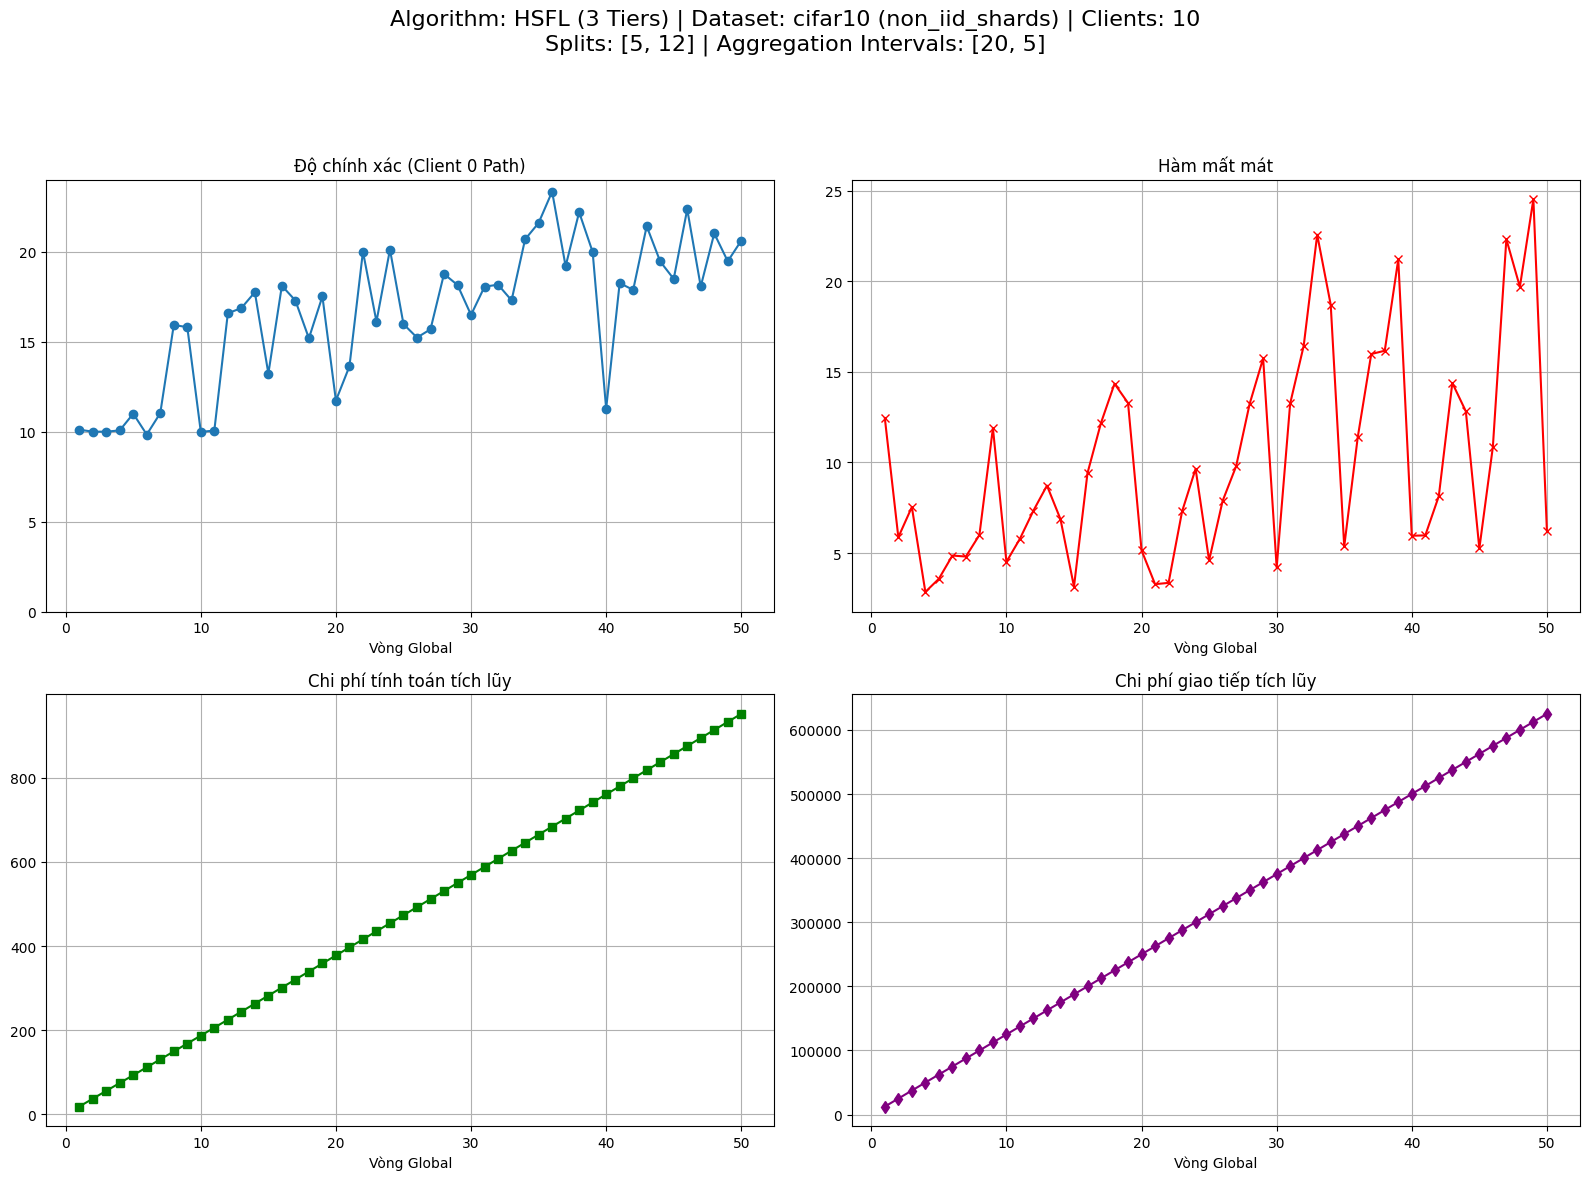

In [17]:
# Cell 6: Trực quan hóa kết quả 📊
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
title = (f"Algorithm: {config.ALGORITHM.upper()} ({config.NUM_TIERS} Tiers) | Dataset: {data_params['dataset_name']} "
         f"({data_params['distribution_mode']}) | Clients: {total_num_clients}\n"
         f"Splits: {config.SPLIT_LAYERS} | Aggregation Intervals: {config.AGGREGATION_INTERVALS}")
fig.suptitle(title, fontsize=16) # Smaller font for longer title
rounds = history['rounds']
axes[0, 0].plot(rounds, history['accuracy'], marker='o'); axes[0, 0].set_title("Độ chính xác (Client 0 Path)"); axes[0, 0].grid(True); axes[0, 0].set_ylim(bottom=0)
axes[0, 1].plot(rounds, history['loss'], marker='x', color='r'); axes[0, 1].set_title("Hàm mất mát"); axes[0, 1].grid(True)
axes[1, 0].plot(rounds, np.cumsum(history['comp_cost']), marker='s', color='g'); axes[1, 0].set_title("Chi phí tính toán tích lũy"); axes[1, 0].grid(True)
axes[1, 1].plot(rounds, np.cumsum(history['comm_cost']), marker='d', color='purple'); axes[1, 1].set_title("Chi phí giao tiếp tích lũy"); axes[1, 1].grid(True)
for ax in axes.flat: ax.set_xlabel("Vòng Global")
plt.tight_layout(rect=[0, 0, 1, 0.92]); plt.show() # Adjust layout for long title